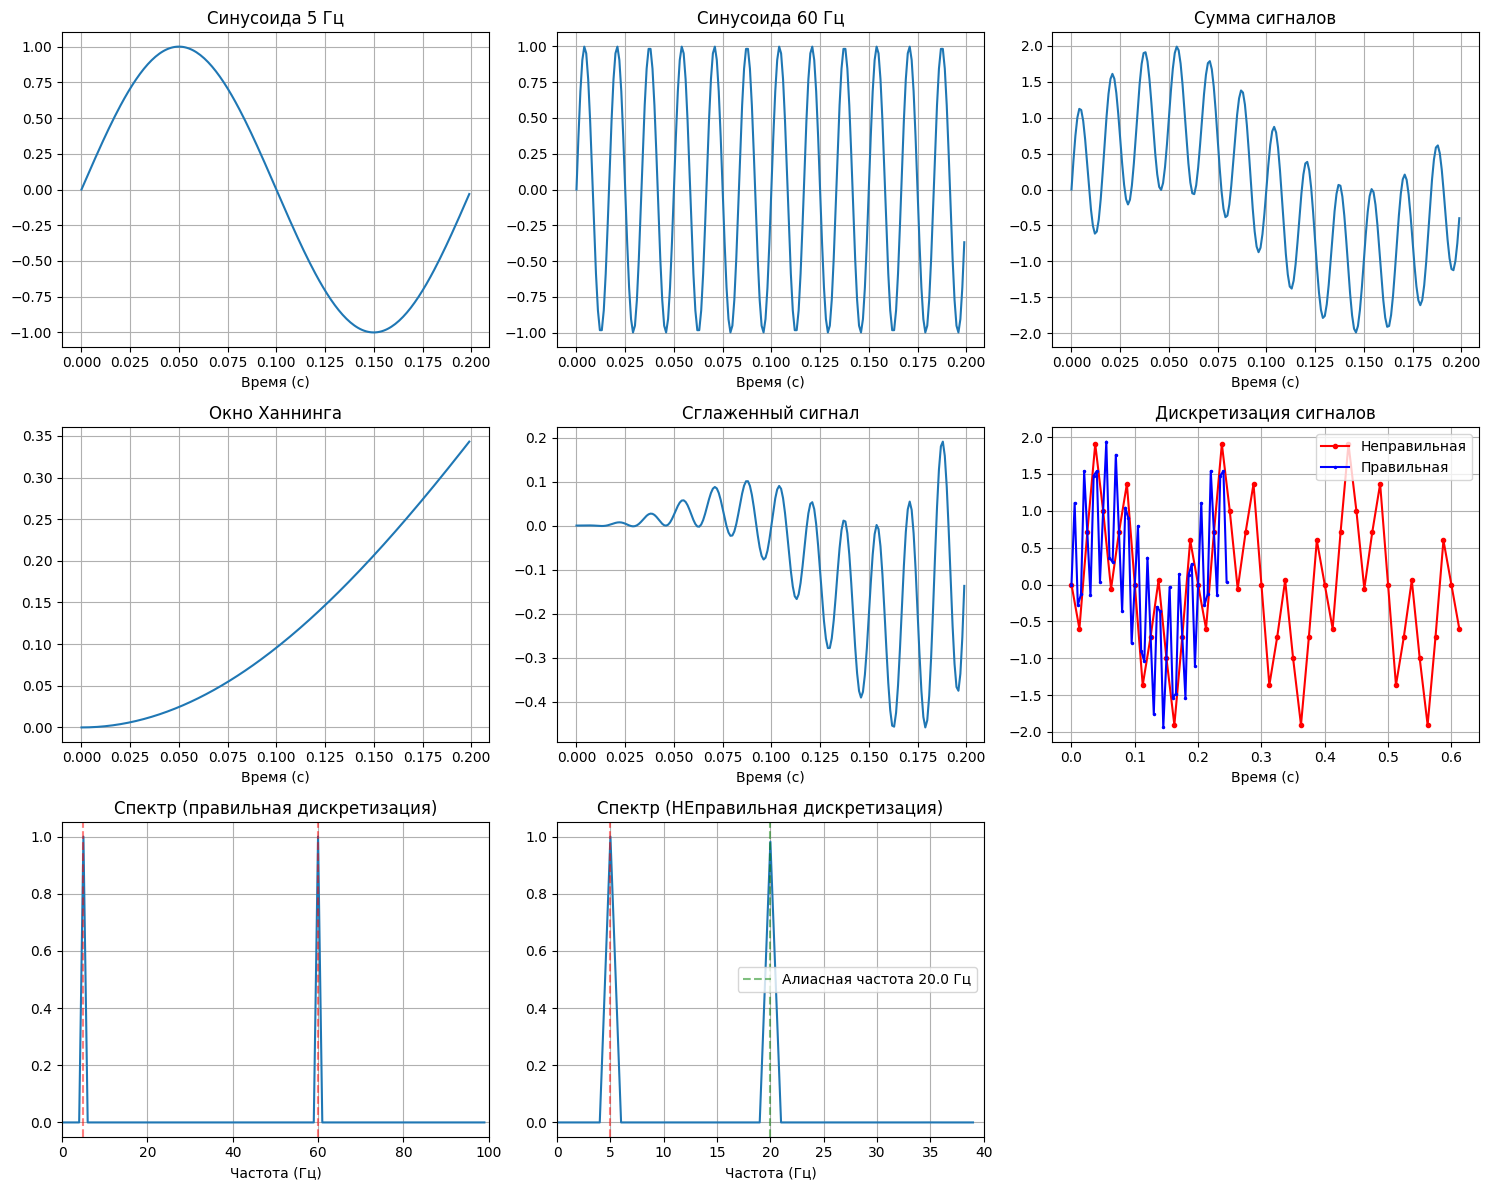

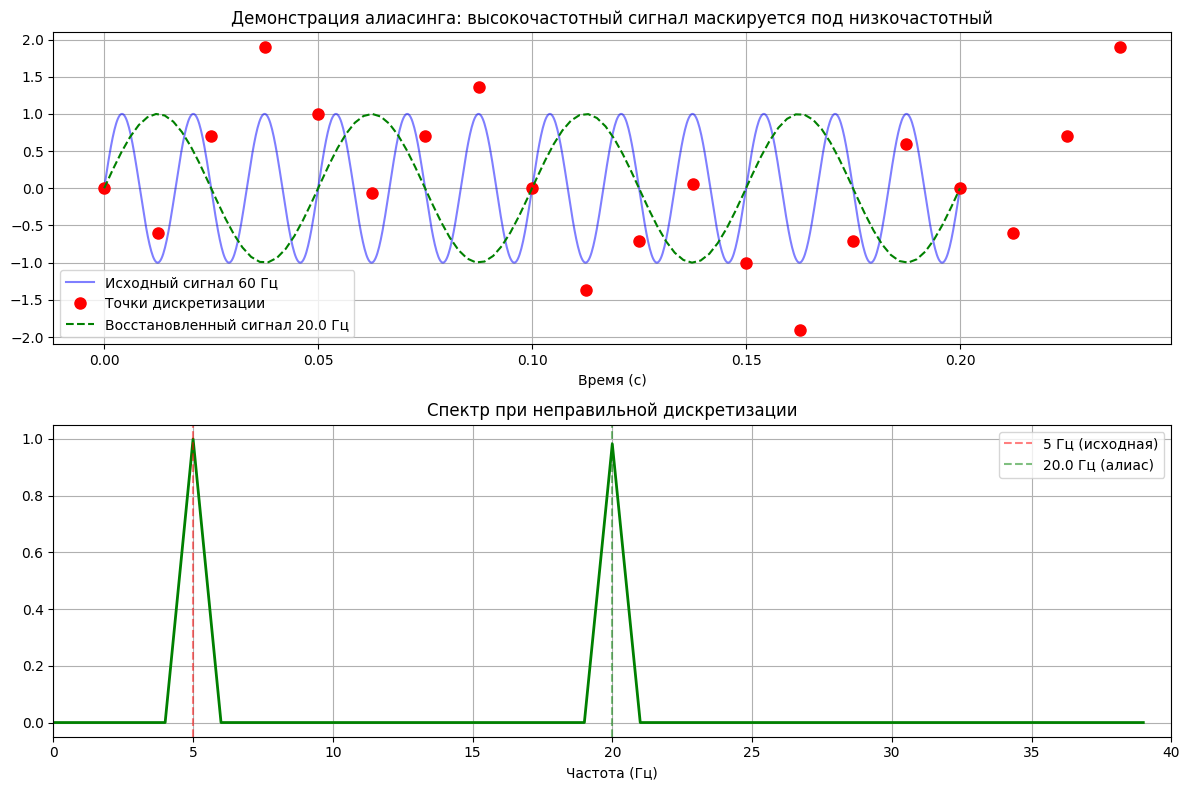

=== Анализ дискретизации ===
Частота сигнала 1: 5 Гц
Частота сигнала 2: 60 Гц
Частота дискретизации (правильная): 200 Гц
Частота дискретизации (неправильная): 80 Гц
Теорема Найквиста: fs > 2*60 = 120 Гц

При неправильной дискретизации частота 60 Гц маскируется под 20.0 Гц
Это и есть эффект наложения спектров (алиасинг)


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq

# Настройка отображения
plt.rcParams['figure.figsize'] = [15, 10]
plt.rcParams['figure.dpi'] = 100

# 1. Создание исходных сигналов (синусоиды из прошлого)
# Возьмем две синусоиды с разными частотами
f1 = 5    # Гц - низкая частота
f2 = 60   # Гц - высокая частота
fs_original = 1000  # Высокая частота дискретизации для исходного сигнала
t_original = np.arange(0, 1, 1/fs_original)

# Создаем сигналы
signal1 = np.sin(2 * np.pi * f1 * t_original)
signal2 = np.sin(2 * np.pi * f2 * t_original)
signal_sum = signal1 + signal2

# 2. Сглаживание по краям (оконное сглаживание)
# Используем окно Ханнинга для плавного спада к краям
window = np.hanning(len(t_original))
signal_smoothed = signal_sum * window

# 3. Дискретизация с разными частотами
# Правильная дискретизация (согласно Найквисту)
fs_correct = 200  # > 2*f2 = 100 Гц
t_correct = np.arange(0, 1, 1/fs_correct)
signal_correct = signal1[::fs_original//fs_correct] + signal2[::fs_original//fs_correct]

# Неправильная дискретизация (с алиасингом)
fs_wrong = 80  # < 2*f2 = 100 Гц
t_wrong = np.arange(0, 1, 1/fs_wrong)
# Интерполируем исходный сигнал для неправильной дискретизации
from scipy import interpolate
f_interp = interpolate.interp1d(t_original, signal_sum, kind='linear')
signal_wrong = f_interp(t_wrong)

# 4. Расчет спектров
def plot_spectrum(signal, fs, title):
    N = len(signal)
    yf = fft(signal)
    xf = fftfreq(N, 1/fs)[:N//2]
    magnitudes = 2.0/N * np.abs(yf[:N//2])
    return xf, magnitudes

# Спектры для правильной и неправильной дискретизации
xf_correct, mag_correct = plot_spectrum(signal_correct, fs_correct, "")
xf_wrong, mag_wrong = plot_spectrum(signal_wrong, fs_wrong, "")

# 5. Визуализация
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

# Первая строка - исходные сигналы
axes[0,0].plot(t_original[:200], signal1[:200])
axes[0,0].set_title(f'Синусоида {f1} Гц')
axes[0,0].set_xlabel('Время (с)')
axes[0,0].grid(True)

axes[0,1].plot(t_original[:200], signal2[:200])
axes[0,1].set_title(f'Синусоида {f2} Гц')
axes[0,1].set_xlabel('Время (с)')
axes[0,1].grid(True)

axes[0,2].plot(t_original[:200], signal_sum[:200])
axes[0,2].set_title('Сумма сигналов')
axes[0,2].set_xlabel('Время (с)')
axes[0,2].grid(True)

# Вторая строка - сглаживание и дискретизация
axes[1,0].plot(t_original[:200], window[:200])
axes[1,0].set_title('Окно Ханнинга')
axes[1,0].set_xlabel('Время (с)')
axes[1,0].grid(True)

axes[1,1].plot(t_original[:200], signal_smoothed[:200])
axes[1,1].set_title('Сглаженный сигнал')
axes[1,1].set_xlabel('Время (с)')
axes[1,1].grid(True)

axes[1,2].plot(t_wrong[:50], signal_wrong[:50], 'ro-', markersize=3, label='Неправильная')
axes[1,2].plot(t_correct[:50], signal_correct[:50], 'b.-', markersize=3, label='Правильная')
axes[1,2].set_title('Дискретизация сигналов')
axes[1,2].set_xlabel('Время (с)')
axes[1,2].legend()
axes[1,2].grid(True)

# Третья строка - спектры
axes[2,0].plot(xf_correct, mag_correct)
axes[2,0].set_title('Спектр (правильная дискретизация)')
axes[2,0].set_xlabel('Частота (Гц)')
axes[2,0].set_xlim([0, 100])
axes[2,0].grid(True)
# Отметим частоты исходных сигналов
axes[2,0].axvline(f1, color='r', linestyle='--', alpha=0.5)
axes[2,0].axvline(f2, color='r', linestyle='--', alpha=0.5)

axes[2,1].plot(xf_wrong, mag_wrong)
axes[2,1].set_title('Спектр (НЕправильная дискретизация)')
axes[2,1].set_xlabel('Частота (Гц)')
axes[2,1].set_xlim([0, 40])
axes[2,1].grid(True)
axes[2,1].axvline(f1, color='r', linestyle='--', alpha=0.5)
# Покажем алиасную частоту
f_alias = abs(f2 - fs_wrong)  # Частота алиасинга
axes[2,1].axvline(f_alias, color='g', linestyle='--', alpha=0.5, label=f'Алиасная частота {f_alias:.1f} Гц')
axes[2,1].legend()

axes[2,2].axis('off')  # Оставим пустым

plt.tight_layout()
plt.show()

# Дополнительная визуализация для демонстрации алиасинга
fig2, axes2 = plt.subplots(2, 1, figsize=(12, 8))

# Покажем исходный сигнал и точки дискретизации
t_dense = np.linspace(0, 0.2, 1000)
signal_dense = np.sin(2*np.pi*f2*t_dense)

axes2[0].plot(t_dense, signal_dense, 'b-', alpha=0.5, label=f'Исходный сигнал {f2} Гц')
axes2[0].plot(t_wrong[:20], signal_wrong[:20], 'ro', markersize=8, label='Точки дискретизации')
# Покажем восстановленный сигнал из-за алиасинга
t_reconstructed = np.linspace(0, 0.2, 100)
signal_reconstructed = np.sin(2*np.pi*f_alias*t_reconstructed)
axes2[0].plot(t_reconstructed, signal_reconstructed, 'g--', label=f'Восстановленный сигнал {f_alias:.1f} Гц')
axes2[0].set_title('Демонстрация алиасинга: высокочастотный сигнал маскируется под низкочастотный')
axes2[0].set_xlabel('Время (с)')
axes2[0].legend()
axes2[0].grid(True)

axes2[1].plot(xf_wrong, mag_wrong, 'g-', linewidth=2)
axes2[1].set_title('Спектр при неправильной дискретизации')
axes2[1].set_xlabel('Частота (Гц)')
axes2[1].set_xlim([0, 40])
axes2[1].grid(True)
axes2[1].axvline(f1, color='r', linestyle='--', alpha=0.5, label=f'{f1} Гц (исходная)')
axes2[1].axvline(f_alias, color='g', linestyle='--', alpha=0.5, label=f'{f_alias:.1f} Гц (алиас)')
axes2[1].legend()

plt.tight_layout()
plt.show()

# Вывод информации
print("=== Анализ дискретизации ===")
print(f"Частота сигнала 1: {f1} Гц")
print(f"Частота сигнала 2: {f2} Гц")
print(f"Частота дискретизации (правильная): {fs_correct} Гц")
print(f"Частота дискретизации (неправильная): {fs_wrong} Гц")
print(f"Теорема Найквиста: fs > 2*{f2} = {2*f2} Гц")
print(f"\nПри неправильной дискретизации частота {f2} Гц маскируется под {f_alias:.1f} Гц")
print(f"Это и есть эффект наложения спектров (алиасинг)")

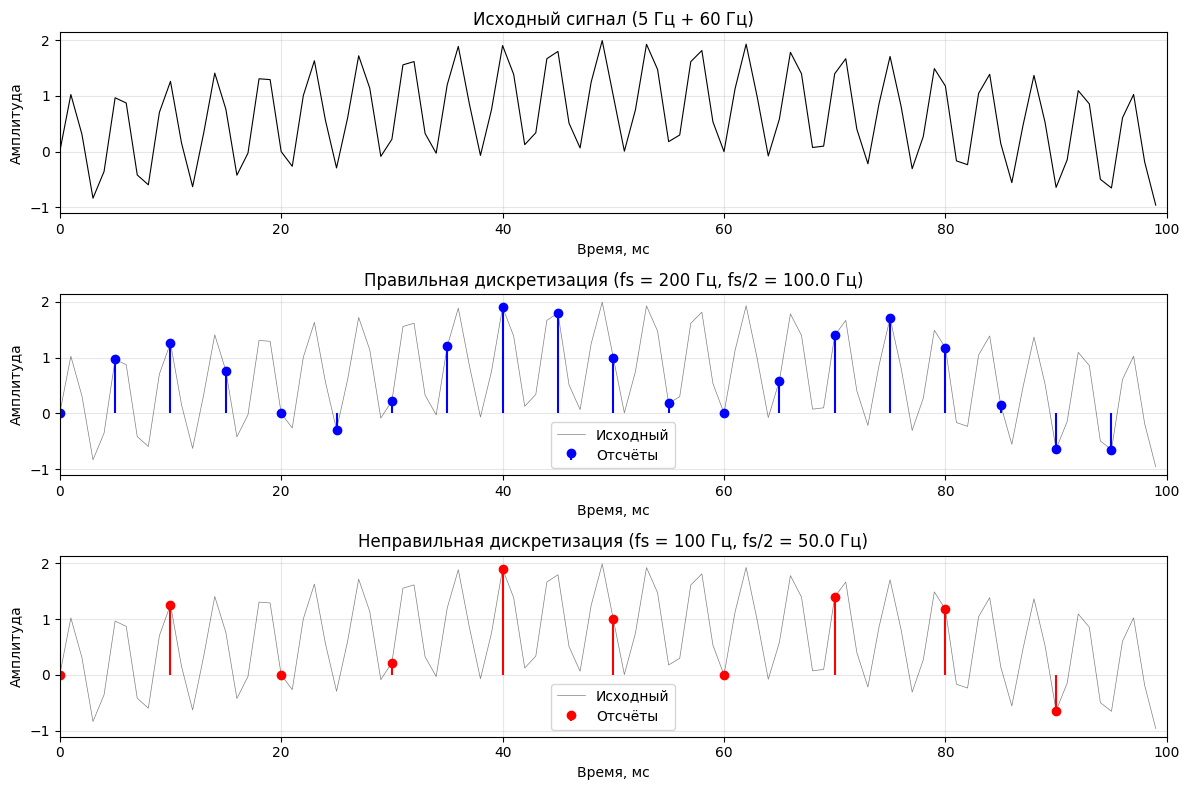

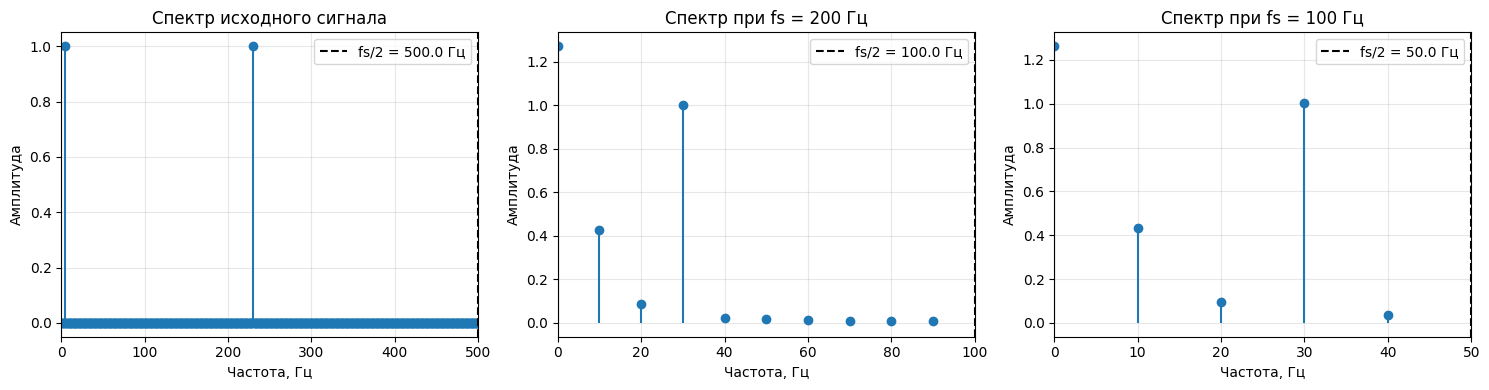

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# Параметры исходного "аналогового" сигнала (высокая частота дискретизации)
fs_orig = 1000      # Гц, моделируем непрерывное время
T = 0.1             # длительность, с
t_orig = np.linspace(0, T, int(fs_orig * T), endpoint=False)

# Сигналы
f1, f2 = 5, 230
signal_orig = np.sin(2 * np.pi * f1 * t_orig) + np.sin(2 * np.pi * f2 * t_orig)

# -------------------------------------------------------------------
# Дискретизация с разными частотами
# -------------------------------------------------------------------
fs_correct = 200    # > 2*60 = 120 Гц – правильная
fs_alias    = 100    # < 2*60 = 120 Гц – вызовет алиасинг

# Шаг дискретизации в единицах исходного времени
step_correct = int(fs_orig / fs_correct)
step_alias    = int(fs_orig / fs_alias)

# Берём каждый step-й отсчёт из исходного массива
t_correct = t_orig[::step_correct]
t_alias   = t_orig[::step_alias]

signal_correct = signal_orig[::step_correct]
signal_alias   = signal_orig[::step_alias]

# -------------------------------------------------------------------
# Визуализация во временной области
# -------------------------------------------------------------------
plt.figure(figsize=(12, 8))

# Исходный сигнал (показан непрерывной линией)
plt.subplot(3, 1, 1)
plt.plot(t_orig * 1000, signal_orig, 'k-', linewidth=0.8, label='Исходный (аналоговый)')
plt.title('Исходный сигнал (5 Гц + 60 Гц)')
plt.xlabel('Время, мс')
plt.ylabel('Амплитуда')
plt.grid(True, alpha=0.3)
plt.xlim(0, T * 1000)

# Правильная дискретизация
plt.subplot(3, 1, 2)
plt.plot(t_orig * 1000, signal_orig, 'k-', linewidth=0.5, alpha=0.5, label='Исходный')
plt.stem(t_correct * 1000, signal_correct, linefmt='b-', markerfmt='bo', basefmt=' ', label='Отсчёты')
plt.title(f'Правильная дискретизация (fs = {fs_correct} Гц, fs/2 = {fs_correct/2} Гц)')
plt.xlabel('Время, мс')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, T * 1000)

# Неправильная дискретизация (алиасинг)
plt.subplot(3, 1, 3)
plt.plot(t_orig * 1000, signal_orig, 'k-', linewidth=0.5, alpha=0.5, label='Исходный')
plt.stem(t_alias * 1000, signal_alias, linefmt='r-', markerfmt='ro', basefmt=' ', label='Отсчёты')
plt.title(f'Неправильная дискретизация (fs = {fs_alias} Гц, fs/2 = {fs_alias/2} Гц)')
plt.xlabel('Время, мс')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, T * 1000)

plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# Анализ спектров
# -------------------------------------------------------------------
def plot_spectrum(signal, fs, title, ax):
    N = len(signal)
    yf = fft(signal)
    xf = fftfreq(N, 1/fs)[:N//2]
    magnitudes = 2.0/N * np.abs(yf[:N//2])
    ax.stem(xf, magnitudes, basefmt=' ')
    ax.set_title(title)
    ax.set_xlabel('Частота, Гц')
    ax.set_ylabel('Амплитуда')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, fs/2)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

# Спектр исходного сигнала (берём длинный отрезок, чтобы разрешение было хорошим)
# Для чистоты эксперимента возьмём больше точек исходного сигнала (целое число периодов)
T_long = 1.0  # 1 секунда
t_long = np.linspace(0, T_long, int(fs_orig * T_long), endpoint=False)
signal_long = np.sin(2*np.pi*f1*t_long) + np.sin(2*np.pi*f2*t_long)
plot_spectrum(signal_long, fs_orig, 'Спектр исходного сигнала', ax1)
ax1.axvline(fs_orig/2, color='k', linestyle='--', label=f'fs/2 = {fs_orig/2} Гц')
ax1.legend()

# Спектр после правильной дискретизации (200 Гц)
plot_spectrum(signal_correct, fs_correct, f'Спектр при fs = {fs_correct} Гц', ax2)
ax2.axvline(fs_correct/2, color='k', linestyle='--', label=f'fs/2 = {fs_correct/2} Гц')
ax2.legend()

# Спектр после неправильной дискретизации (100 Гц)
plot_spectrum(signal_alias, fs_alias, f'Спектр при fs = {fs_alias} Гц', ax3)
ax3.axvline(fs_alias/2, color='k', linestyle='--', label=f'fs/2 = {fs_alias/2} Гц')
ax3.legend()

plt.tight_layout()
plt.show()

Чтостато алиаса Fali = |частота сигнала - частота дискретизации|

Частота Найквиста : Fs / 2 = 50Гц
Сигнал: 70Гц  > 50 Гц -> попадает в зону наложения
При дескритизации спектр копируется с периодом Fs = 100Гц. Оригинальный пик на 70Гц даёт копинаю на 70 - 100 = -30Гц,
что для действительного сигнала эквивалента частоте +30Гц 

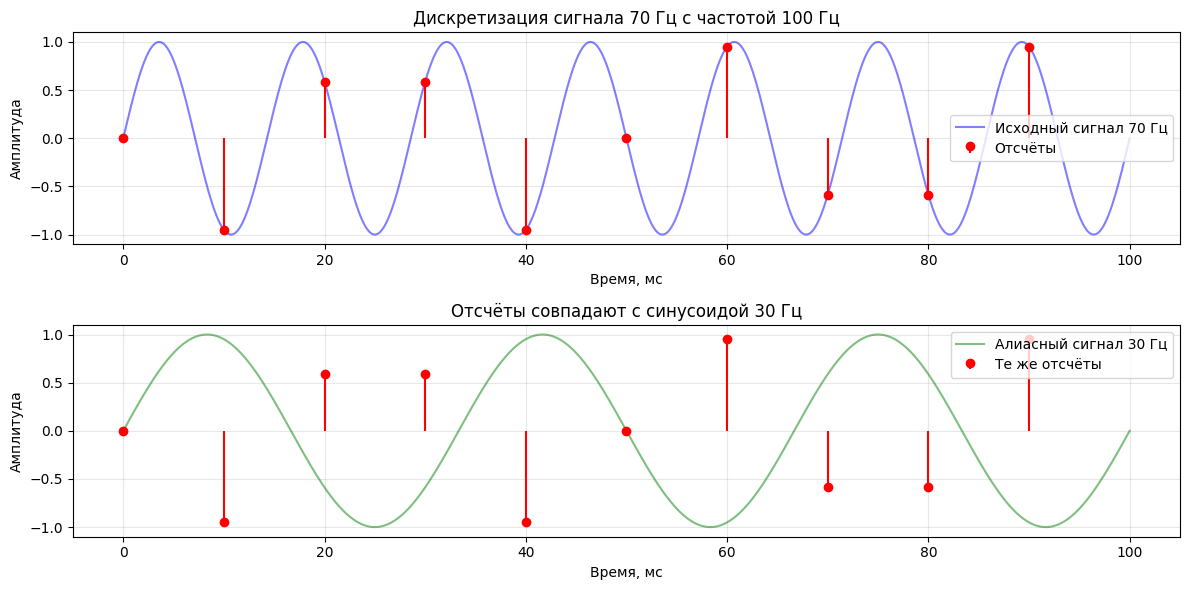

In [12]:
# Параметры
fs = 100          # частота дискретизации
T = 0.1           # длительность (0.1 с = 10 периодов для 70 Гц, но для наглядности возьмём 0.1 с)
t_cont = np.linspace(0, T, 1000)          # «непрерывное» время для построения гладких кривых
t_sample = np.arange(0, T, 1/fs)          # моменты дискретизации

# Сигналы
f_orig = 70
f_alias = 30

y_orig_cont = np.sin(2 * np.pi * f_orig * t_cont)
y_orig_sample = np.sin(2 * np.pi * f_orig * t_sample)

y_alias_cont = np.sin(2 * np.pi * f_alias * t_cont)
y_alias_sample = np.sin(2 * np.pi * f_alias * t_sample)

# Построение
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(t_cont*1000, y_orig_cont, 'b-', label=f'Исходный сигнал {f_orig} Гц', alpha=0.5)
plt.stem(t_sample*1000, y_orig_sample, linefmt='r-', markerfmt='ro', basefmt=' ', label='Отсчёты')
plt.title(f'Дискретизация сигнала {f_orig} Гц с частотой {fs} Гц')
plt.xlabel('Время, мс')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(t_cont*1000, y_alias_cont, 'g-', label=f'Алиасный сигнал {f_alias} Гц', alpha=0.5)
plt.stem(t_sample*1000, y_orig_sample, linefmt='r-', markerfmt='ro', basefmt=' ', label='Те же отсчёты')
plt.title(f'Отсчёты совпадают с синусоидой {f_alias} Гц')
plt.xlabel('Время, мс')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

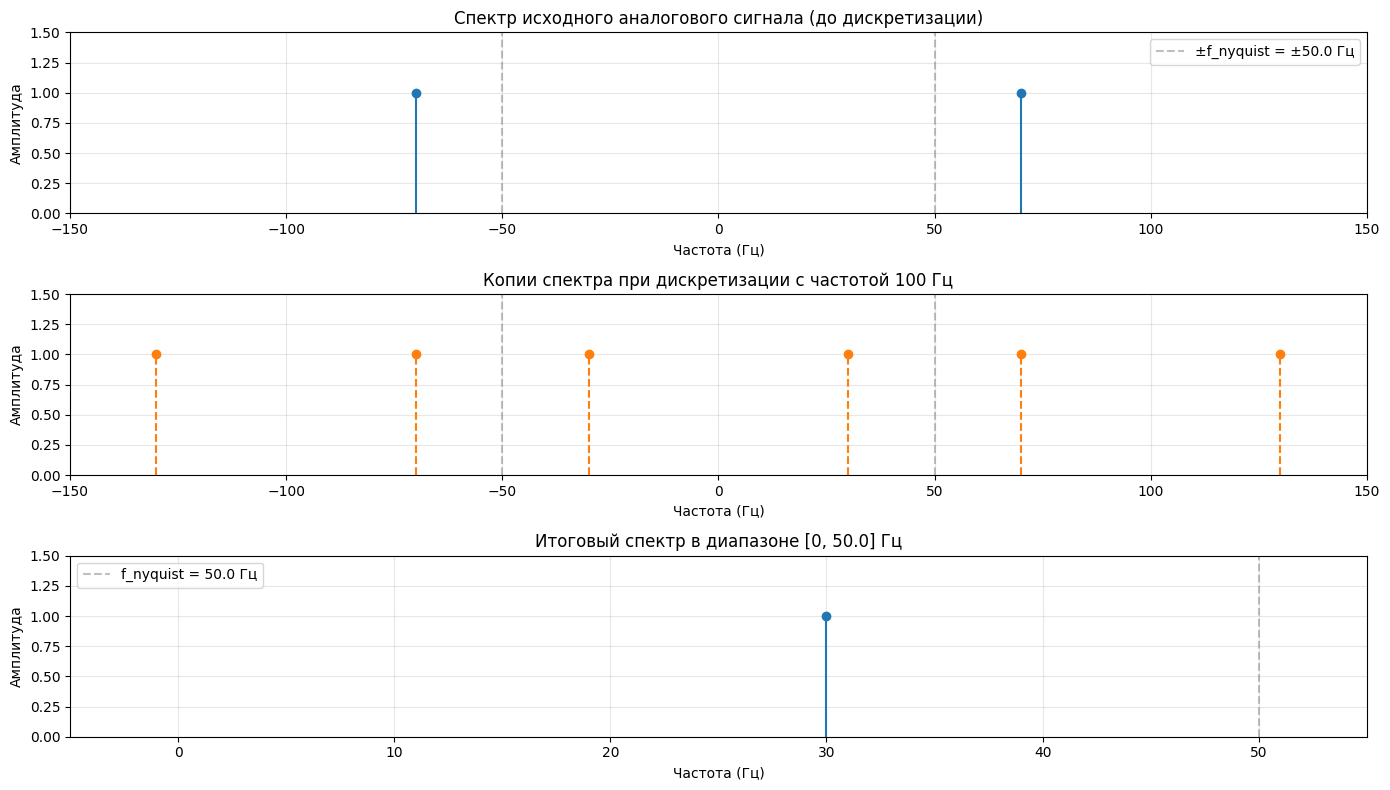

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Параметры
f_signal = 70
f_s = 100
f_nyquist = f_s/2

# Создаём диапазон частот для отображения
freqs = np.linspace(-150, 150, 1000)

# Исходный спектр (два пика: на +70 и -70)
spectrum_orig = (np.abs(freqs - f_signal) < 1) + (np.abs(freqs + f_signal) < 1)

# Копии спектра (периодическое продолжение)
spectrum_copy = np.zeros_like(freqs)
for k in range(-2, 3):
    spectrum_copy += (np.abs(freqs - (f_signal + k*f_s)) < 1) + (np.abs(freqs + (f_signal + k*f_s)) < 1)

# То, что остаётся после дискретизации (свёртка с гребёнкой Дирака)
# На самом деле это просто сумма всех копий, но для наглядности покажем копии отдельно

plt.figure(figsize=(14, 8))

# Исходный спектр (до дискретизации)
plt.subplot(3, 1, 1)
plt.stem([-f_signal, f_signal], [1, 1], basefmt=' ')
plt.xlim(-150, 150)
plt.ylim(0, 1.5)
plt.title('Спектр исходного аналогового сигнала (до дискретизации)')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.grid(alpha=0.3)
plt.axvline(-f_nyquist, color='gray', linestyle='--', alpha=0.5)
plt.axvline(f_nyquist, color='gray', linestyle='--', alpha=0.5, label=f'±f_nyquist = ±{f_nyquist} Гц')
plt.legend()

# Копии спектра после дискретизации
plt.subplot(3, 1, 2)
for k in range(-2, 3):
    plt.stem([-f_signal + k*f_s, f_signal + k*f_s], [1, 1], linefmt='C1--', markerfmt='C1o', basefmt=' ')
plt.xlim(-150, 150)
plt.ylim(0, 1.5)
plt.title(f'Копии спектра при дискретизации с частотой {f_s} Гц')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.grid(alpha=0.3)
plt.axvline(-f_nyquist, color='gray', linestyle='--', alpha=0.5)
plt.axvline(f_nyquist, color='gray', linestyle='--', alpha=0.5)

# Результирующий спектр дискретизированного сигнала (в диапазоне Найквиста)
plt.subplot(3, 1, 3)
# Найдём все копии, попадающие в [-f_nyquist, f_nyquist]
aliased_freqs = []
for k in range(-2, 3):
    f1 = -f_signal + k*f_s
    f2 = f_signal + k*f_s
    if -f_nyquist <= f1 <= f_nyquist:
        aliased_freqs.append(f1)
    if -f_nyquist <= f2 <= f_nyquist:
        aliased_freqs.append(f2)
# Убираем дубликаты и берём абсолютные значения для положительного отображения
# ... после получения aliased_freqs
aliased_freqs = np.unique(np.abs(aliased_freqs))
# Создаём массив амплитуд, равный по длине aliased_freqs
amplitudes = np.ones_like(aliased_freqs)
plt.stem(aliased_freqs, amplitudes, basefmt=' ')
plt.xlim(-5, 55)
plt.ylim(0, 1.5)
plt.title(f'Итоговый спектр в диапазоне [0, {f_nyquist}] Гц')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.grid(alpha=0.3)
plt.axvline(f_nyquist, color='gray', linestyle='--', alpha=0.5, label=f'f_nyquist = {f_nyquist} Гц')
plt.legend()

plt.tight_layout()
plt.show()